In [4]:

import numpy as np
import scipy.stats as st
from scipy.optimize import fmin, differential_evolution
import glob
import pandas as pd
import pickle
import math


### Comment Chris: This function processes the subject data. Note that you should have the data stored in a specific subdirectory (all_data)
def clean_data():
    """
    Inputs: raw data
    Outputs: <1> subjective estimates est[i,j,k] --> p_data in main
                 i-th participant, j-th query, and k-th repetition
             <2> queryOrder --> the only order we clean data and generate model predictions
    """
    all_data = glob.glob('all_data/*.csv') # data directory
    numPar = len(all_data) # total no. of participants
    print(numPar,' participants were considered!')
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++++++')

    est = np.zeros(shape=(numPar,60,3))
    # est[i,j,k] meaning:
    # probability estimates of i-th participant, j-th query, and k-th repetition of the same query
    neg, land, lor, lg = ' not', ' and', ' or', ' given'
    eventAs = [' cold', ' windy', ' warm']
    eventBs = [' rainy', ' cloudy', ' snowy']
    queryOrder = []
    for A, B in zip(eventAs, eventBs):
        queryOrder.append(A)
        queryOrder.append(B)
        queryOrder.append(neg + A)
        queryOrder.append(neg + B)
        queryOrder.append(A + land + B)
        queryOrder.append(B + land + neg + A) #queryOrder.append(neg + A + land + B)
        queryOrder.append(A + land + neg + B)
        queryOrder.append(neg + A + land + neg + B)
        queryOrder.append(A + lor + B)
        queryOrder.append(B + lor + neg + A) #queryOrder.append(neg + A + lor + B)
        queryOrder.append(A + lor + neg + B)
        queryOrder.append(neg + A + lor + neg + B)
        queryOrder.append(A + lg + B)
        queryOrder.append(neg + A + lg + B)
        queryOrder.append(A + lg + neg + B)
        queryOrder.append(neg + A + lg + neg + B)
        queryOrder.append(B + lg + A)
        queryOrder.append(neg + B + lg + A)
        queryOrder.append(B + lg + neg + A)
        queryOrder.append(neg + B + lg + neg + A)


    for i,fname in enumerate(all_data): # loop through data files
        print('Processing Participant No.%d' % (i+1), fname)
        print('________________________________________________________')

        df = pd.read_csv(fname)  # read data
        for j,q in enumerate(queryOrder): # loop through query
            nowEst = df[df['querydetail']==q]['estimate']
            nowEstValues = nowEst.values/100
            for k in range(3):
                est[i,j,k] = nowEstValues[k]

    # save cleaned dataset
    with open('pEstData.pkl','wb') as f:
        pickle.dump({'data': est, 'query_order': queryOrder}, f)
    return est, queryOrder

##Comment Chris: function to calculate various probabilities
def get_truePr_BS(a,b,c,d):
    truePr = []
    base = a+b+c+d
    truePr.append((a+c)/base)
    truePr.append((a+b)/base)
    truePr.append((b+d)/base)
    truePr.append((c+d)/base)
    truePr.append(a/base)
    truePr.append(b/base)
    truePr.append(c/base)
    truePr.append(d/base)
    truePr.append((a+b+c)/base)
    truePr.append((a+b+d)/base)
    truePr.append((a+c+d)/base)
    truePr.append((b+c+d)/base)
    truePr.append((a/(a+b)))
    truePr.append((b/(a+b)))
    truePr.append((c/(c+d)))
    truePr.append((d/(c+d)))
    truePr.append((a/(a+c)))
    truePr.append((c/(a+c)))
    truePr.append((b/(b+d)))
    truePr.append((d/(b+d)))

    return truePr



### Comment Chris: function that generates the model and calculates MSE. This function is called by the function MSE_BS
def generativeModel_BS(params,N,beta):
    """
    notice N and N2 are global parameters predetermined
    give a set of free parameters for BS model
     --> output the model predicted distributions for all querys
    """
    a,b,c,d = [0,0],[0,0],[0,0],[0,0]
    a[0],b[0],c[0],d[0],a[1],b[1],c[1],d[1] = params
    N2 = N
    MSE = 0

    allpredmeans = np.zeros((40,))


    for iter in range(2):
        sum_of_truePr = a[iter]+b[iter]+c[iter]+d[iter]
        MSE += (sum_of_truePr/100-1)**2/2 # make sure a+b+c+d is close to 100

        truePr = get_truePr_BS(a[iter], b[iter], c[iter], d[iter])

        for i, trueP in enumerate(truePr):
            if i<4 or i>=12: # simple and conditionals
                allpredmeans[i+iter*20] = trueP*N/(N+2*beta)+beta/(N+2*beta) ### Chris: This is unique to BS model: calculation with N and beta is used
            else: # conjunctions and disjunctions
                allpredmeans[i+iter*20] = trueP*N2/(N2+2*beta)+beta/(N2+2*beta)   ### Chris: This is unique to BS model: calculation with N and beta is used

    return allpredmeans, MSE


### Comment Chris: this function is called by the evolutionaary model. The function gets bounds as parameters and then tries to find the best parameters that fall within those bounds to minimize MSE
def MSE_BS(params):
    """
    compute the MSE distance of model prediction <--> actual data
    """
    allpredmeans, MSE = generativeModel_BS(params, current_N, current_beta)
    for i in range(len(allpredmeans)):
        currentdata = testdata[i,:].flatten()
        MSE += np.mean((allpredmeans[i] - currentdata) ** 2)/40  #### Chris: there are 40 unique sentences to test. So, calculate mean over 40 (20 per category)

    return MSE



## Comment Chris: function that goes through all participants and finds the best fit for them
def init_fit_BS():
    """
    initialize model fitting practice for Bayesian sampling model
    """
    global testdata, current_N, current_beta
    print(np.shape(pData))
    bnds = [(0.0, 100), (0.0, 100), (0.0, 100), (0.0, 100),
            (0.0, 100), (0.0, 100), (0.0, 100), (0.0, 100)] #,
            #(0,1), (1,250)]

    betaSS = [0.1,0.5,1,2,5]
    nSS = [1,2,5,10,50,100]

    resultFrame = pd.DataFrame(index=nSS, columns=betaSS)

    totBIC = 0
    trail = 0

    for thisBeta in betaSS:
        for thisN in nSS:
            trail += 1
            totalMSE = 0
            print('Trail: ' + str(trail) + '  N: ' + str(thisN) + '  Beta: ' + str(thisBeta))

            current_N = thisN
            current_beta = thisBeta
            for ipar in range(10):  # loop through participants
                minMSE, n_data, BIC = 0, 0, 0
                n_para = 6  # effective number of parameters: [a,b,c]*2, beta/(n+2beta), beta/(n2+2beta)
                testdata = pData[ipar,:,:]
                fit_all_data = differential_evolution(MSE_BS, bounds=bnds,
                                                      popsize=30,
                                                      disp=False, polish=fmin, tol = 1e-5)
                print(fit_all_data.x, fit_all_data.fun)

                minMSE = fit_all_data.fun
                totalMSE += minMSE
                n_data = 40*3

                allpredmeans, _ = generativeModel_BS(fit_all_data.x,current_N,current_beta)

                ### Comment Chris: once you are at the relevant part of the assignment, replace the "=0" with a call to your function that calculates the BIC
                BIC = n_data * np.log10(minMSE) + np.log10(n_data) * (n_para + 1) + n_data * np.log10(2*math.pi) + n_para
                totBIC += BIC

                print('BIC score of Bayesian sampling model:', BIC)

                # model 1,2 = Bayesian sampling (1:one sample size, 2:two sample sizes)
                # model 3   = Sampling/RF
                saved_location = 'fit_results2/part_'+str(ipar)+'_model_1.pkl'
                with open(saved_location, 'wb') as f:
                    pickle.dump({'fitResults': fit_all_data,
                                 'predmean': allpredmeans,
                                 'bic':BIC}, f)

            resultFrame.at[thisN, thisBeta] = totalMSE
            print('N: ' + str(thisN) + '  Beta: ' + str(thisBeta) + '  totMSE: ' + str(totalMSE))

    print('total BIC:', totBIC)
    return resultFrame

################################
#          Main Code           #
################################
global pData
pData, queryOrder = clean_data()

results = init_fit_BS()


## Comment Chris: this code can be modified to access objects that have been stored in a "pickle" object.
#objects = []
#with open('part_0_model_1.pkl', 'rb') as f:
#    while True:
#        try:
#            objects.append(pickle.load(f))
#        except EOFError:
#            break



84  participants were considered!
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Processing Participant No.1 all_data\PrEstExp_001_111218_115935.csv
________________________________________________________
Processing Participant No.2 all_data\PrEstExp_003_111218_115950.csv
________________________________________________________
Processing Participant No.3 all_data\PrEstExp_004_111218_115958.csv
________________________________________________________
Processing Participant No.4 all_data\PrEstExp_005_111218_120004.csv
________________________________________________________
Processing Participant No.5 all_data\PrEstExp_006_111218_120007.csv
________________________________________________________
Processing Participant No.6 all_data\PrEstExp_007_111218_120016.csv
________________________________________________________
Processing Participant No.7 all_data\PrEstExp_008_111218_120025.csv
________________________________________________________
Processing Participant No.8 all_dat

<ipython-input-4-59ff77a211d8>:87: RuntimeWarning: invalid value encountered in double_scalars
  truePr.append((c/(c+d)))
<ipython-input-4-59ff77a211d8>:88: RuntimeWarning: invalid value encountered in double_scalars
  truePr.append((d/(c+d)))
<ipython-input-4-59ff77a211d8>:91: RuntimeWarning: invalid value encountered in double_scalars
  truePr.append((b/(b+d)))
<ipython-input-4-59ff77a211d8>:92: RuntimeWarning: invalid value encountered in double_scalars
  truePr.append((d/(b+d)))


[9.56696005e+01 4.19988192e-05 1.68936824e+00 2.67701611e+00
 9.99816762e+01 6.93070064e-08 2.08898019e-06 4.89127561e-03] 0.039727494736289885
BIC score of Bayesian sampling model: -51.77320562045891
[9.99855504e+01 0.00000000e+00 2.16355361e-03 5.04400825e-03
 8.78047409e+01 1.21529995e+01 2.06363233e-04 4.91177810e-05] 0.039492543673018486
BIC score of Bayesian sampling model: -52.082334224346866
[9.99638877e+01 2.72906633e-06 1.22300388e-02 9.08132272e-07
 9.99553971e+01 1.05352205e-03 2.73459724e-03 5.09715351e-04] 0.05077275670271214
BIC score of Bayesian sampling model: -38.98845779127545
[5.20466026e+01 4.10738750e-08 4.79569554e+01 1.01400823e-03
 5.42852212e+01 1.67993226e+01 1.69589900e+01 1.19720362e+01] 0.018284362108269253
BIC score of Bayesian sampling model: -92.21456944467396
[17.60289161 30.48112263 25.12577872 26.79455606 28.6759266  41.65115037
 15.71434723 13.97027084] 0.028425462206086795
BIC score of Bayesian sampling model: -69.2192428544394
[8.30285900e+00 1.26

In [5]:
results

,0.1,0.5,1.0,2.0,5.0
1,0.428105,0.339121,0.325694,0.343325,0.391919
2,0.457702,0.37463,0.339121,0.325694,0.354134
5,0.479937,0.428105,0.388139,0.348851,0.325694
10,0.488276,0.457703,0.428105,0.388139,0.339121
50,0.495324,0.488276,0.479938,0.464685,0.428105
100,0.49623,0.49264,0.488276,0.479938,0.457702


In [6]:
resultsReal = results / 10
resultsReal

,0.1,0.5,1.0,2.0,5.0
1,0.04281,0.033912,0.032569,0.034332,0.039192
2,0.04577,0.037463,0.033912,0.032569,0.035413
5,0.047994,0.04281,0.038814,0.034885,0.032569
10,0.048828,0.04577,0.042811,0.038814,0.033912
50,0.049532,0.048828,0.047994,0.046469,0.04281
100,0.049623,0.049264,0.048828,0.047994,0.04577


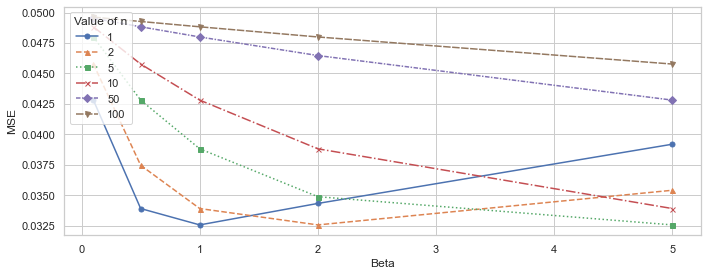

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df: index = N, columns = Beta, values = MSE
# Example structure:
#       0     1     2     5
# 1   ...
# 2   ...
# 5   ...
# 10  ...
# 50  ...
# 100 ...

# --- reshape to long form for seaborn ---
df_long = resultsReal.reset_index().melt(
    id_vars='index',
    var_name='Beta',
    value_name='MSE'
)
df_long = df_long.rename(columns={'index': 'N'})

# convert to numeric in case columns/index were strings
df_long['Beta'] = pd.to_numeric(df_long['Beta'])
df_long['N'] = pd.to_numeric(df_long['N'])

# --- style parameters similar to the R plot ---
sns.set(style="whitegrid")

# markers and linestyles for each N (order should match sorted unique Ns)
unique_N = sorted(df_long['N'].unique())
markers = ['o', '^', 's', 'x', 'D', 'v']  # circle, triangle, square, etc.
linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (3, 1, 1, 1)), (0, (5, 1))]

plt.figure(figsize=(10, 4))

for i, n in enumerate(unique_N):
    sub = df_long[df_long['N'] == n].sort_values('Beta')
    plt.plot(
        sub['Beta'],
        sub['MSE'],
        label=str(n),
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.5,
        markersize=5
    )

plt.xlabel('Beta')
plt.ylabel('MSE')
plt.legend(title='Value of n', frameon=True, loc='upper left')
plt.tight_layout()
plt.show()